# Analiza i čišćenje SMS podataka

Cilj je da razumemo šta se nalazi u originalnom CSV-u i kako od njega nastaje skup za model. Obradu pozivamo iz `src/preprocessing.py`, tako da Jupyter i komandna linija primenjuju isto pravilo.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.data_loading import load_raw_sms
from src.preprocessing import prepare_sms

raw = load_raw_sms()
raw.shape

(5572, 5)

## 1. Struktura i nedostajuće vrednosti

`isna()` pokazuje prazne ćelije. Tri dodatne kolone su skoro prazne, ali 50 redova ima u njima nastavak poruke. Zato ih ne odbacujemo pre spajanja teksta.

In [2]:
print('Prazne ćelije po koloni:')
print(raw.isna().sum().to_string())
extra_columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
continued = raw[extra_columns].notna().any(axis=1)
print('Redovi sa nastavkom:', continued.sum())
raw.loc[continued, ['v1', 'v2', *extra_columns]].head(3)

Prazne ćelije po koloni:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
Redovi sa nastavkom: 50


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN


## 2. Jedno pravilo čišćenja

Delove poruke spajamo zarezom redom kojim stoje u CSV-u i uklanjamo samo praznine na početku i kraju. Ne pretvaramo tekst u mala slova i ne brišemo interpunkciju, jer znakovi i velika slova mogu biti korisni za prepoznavanje spama. Zatim uklanjamo potpuno identične poruke. Ako bi ista poruka imala obe oznake, obrada bi se zaustavila greškom umesto da proizvoljno izabere jednu.

In [3]:
clean = prepare_sms(raw)
print('Originalnih redova:', len(raw))
print('Jedinstvenih poruka:', len(clean))
print('Uklonjenih tačnih duplikata:', len(raw) - len(clean))
print('Preostali duplikati teksta:', clean.duplicated('text').sum())
print('Prazni tekstovi:', clean['text'].eq('').sum())
clean.head(3)

Originalnih redova: 5572
Jedinstvenih poruka: 5158
Uklonjenih tačnih duplikata: 414
Preostali duplikati teksta: 0
Prazni tekstovi: 0


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


## 3. Raspodela klasa

`ham` je regularna, a `spam` neželjena poruka. Pored apsolutnog broja gledamo i udeo, jer neuravnotežen skup utiče na izbor metrika: sama tačnost može da zavara ako model pretežno predviđa većinsku klasu.

       broj  udeo_%
label              
ham    4516   87.55
spam    642   12.45


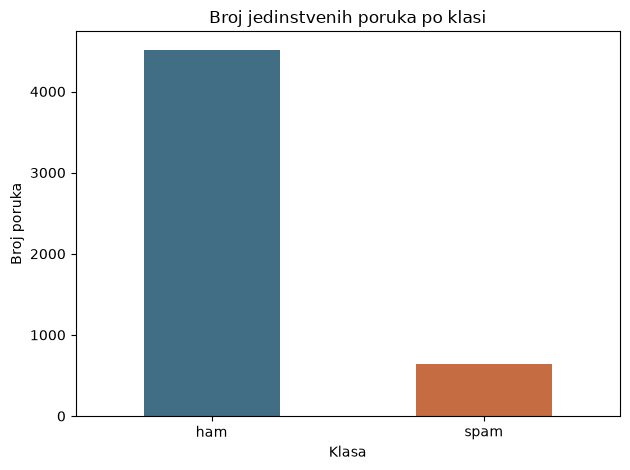

In [4]:
counts = clean['label'].value_counts().reindex(['ham', 'spam'])
print(pd.DataFrame({'broj': counts, 'udeo_%': (counts / len(clean) * 100).round(2)}).to_string())
ax = counts.plot.bar(color=['#416e84', '#c66c43'], rot=0)
ax.set(title='Broj jedinstvenih poruka po klasi', xlabel='Klasa', ylabel='Broj poruka')
plt.tight_layout()
plt.show()

## 4. Dužina poruka

Merimo broj znakova i reči posle čišćenja. Histogram prikazuje koliko su poruke dugačke. Ekstremno dugačke poruke su i dalje prisutne: zbog preglednosti grafika prikazujemo samo opseg do 99. percentila, a pun raspon navodimo brojčano.

      char_count                                                word_count                                          
           count   mean   std   min    25%    50%    75%    max      count  mean   std  min   25%   50%   75%    max
label                                                                                                               
ham       4516.0   71.0  56.7   2.0   34.0   53.0   92.0  910.0     4516.0  14.2  11.2  1.0   7.0  11.0  19.0  171.0
spam       642.0  137.9  30.1  13.0  132.0  148.5  157.0  224.0      642.0  23.7   6.0  2.0  21.2  25.0  28.0   35.0
Najduža poruka: 910 znakova; prikaz do 99. percentila: 267


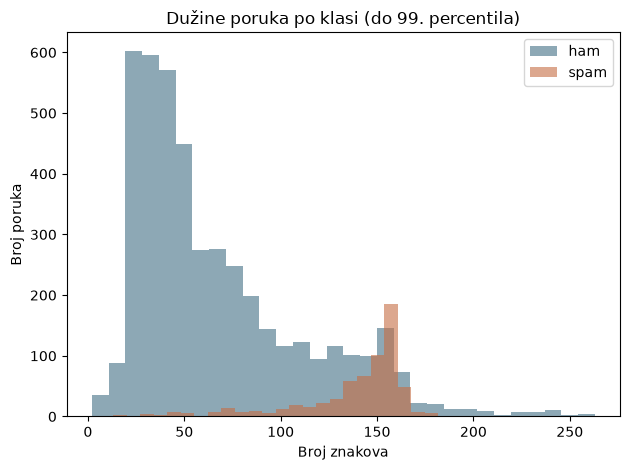

In [5]:
analysis = clean.assign(
    char_count=clean['text'].str.len(),
    word_count=clean['text'].str.split().str.len(),
    is_spam=clean['label'].eq('spam').astype(int),
)
print(analysis.groupby('label')[['char_count', 'word_count']].describe().round(1).to_string())
limit = analysis['char_count'].quantile(0.99)
print('Najduža poruka:', analysis['char_count'].max(), 'znakova; prikaz do 99. percentila:', round(limit))
for label, color in [('ham', '#416e84'), ('spam', '#c66c43')]:
    lengths = analysis.loc[analysis['label'].eq(label), 'char_count']
    plt.hist(lengths[lengths <= limit], bins=30, alpha=0.6, label=label, color=color)
plt.xlabel('Broj znakova')
plt.ylabel('Broj poruka')
plt.title('Dužine poruka po klasi (do 99. percentila)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Korelacije osnovnih numeričkih osobina

Pearsonova korelacija od −1 do 1 meri linearnu vezu. Ovde je koristimo samo opisno: veza dužine i oznake nije dokaz uzročnosti niti procena kvaliteta modela. `is_spam=1` označava spam.

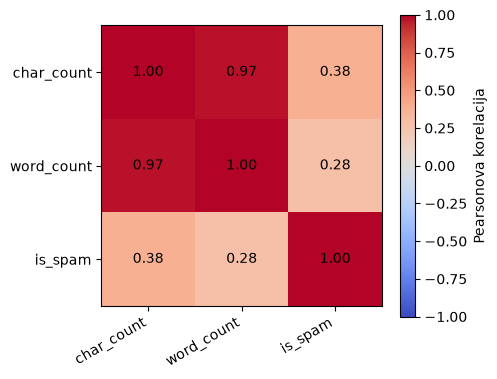

In [6]:
features = ['char_count', 'word_count', 'is_spam']
correlations = analysis[features].corr()
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(correlations, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(features)), features, rotation=30, ha='right')
ax.set_yticks(range(len(features)), features)
for row in range(len(features)):
    for column in range(len(features)):
        ax.text(column, row, f'{correlations.iloc[row, column]:.2f}', ha='center', va='center')
fig.colorbar(image, ax=ax, label='Pearsonova korelacija')
fig.tight_layout()
plt.show()

## Šta dalje?

Ovaj skup još nije podeljen na trening i test. U narednom koraku napravićemo izdvojeni test skup, zatim tokenizaciju i rečnik iz trening dela. Duplikate smo uklonili pre podele da identična poruka ne završi na obe strane.